# Домашняя работа "Тематическое моделирование". Тян Е.В.

## Классификация по тональности

В этом домашнем задании вам предстоит классифицировать по тональности отзывы на банки с сайта banki.ru.
Данные содержат непосредственно тексты отзывов, некоторую дополнительную информацию, а также оценку по шкале от 1 до 5.
Тексты хранятся в json-ах в массиве responses.
Посмотрим на примере отзыва: возьмите для удобства ноутбук, размещенный в папке репозитория.

In [1]:
import pandas as pd
import re
from string import punctuation

In [2]:
responses_df = pd.read_json('banki_responses.json', lines = True).sample(n=10000, random_state=42).reset_index(drop=True)

def preprocess_response(text):
    text = re.sub('[{}]'.format(punctuation+'–—'), '', text.lower()) # уберем пунктуацию
    russian_words_pattern = re.compile(r'\b[а-яА-Я]+\b') # оставим только слова полностью состоящие из русских букв
    return " ".join(russian_words_pattern.findall(text))

responses_df["text"] = responses_df["text"].apply(preprocess_response)
responses_df

,city,rating_not_checked,title,num_comments,bank_license,author,bank_name,datetime,text,rating_grade
0,None,False,АВАНГАРД ВРАНЬЕ,0,лицензия № 2879,Сергей,Авангард,2005-10-27 13:29:00,у банка все ужасно а один из вице презединтов ...,NaN
1,г. Санкт-Петербург,False,Общие впечатления о работе Альфа-Банка,0,лицензия № 1326,dmitriyrachkov,Альфа-Банк,2012-07-25 10:27:00,всем добрый день скажу сразу хочу написать общ...,NaN
2,г. Москва,True,Получение информации по ипотечным кредитам по ...,2,лицензия № 1326,haexichu,Альфа-Банк,2011-12-08 17:02:00,вчера произошел не очень приятный диалог с аль...,2.0
3,г. Москва,False,Не работает On-банк,2,лицензия № 3368,rare_guest,СМП Банк,2012-08-01 13:55:00,сегодня утром открыл текущий в офисе гагаринск...,NaN
4,г. Сочи,False,"""Русский стандарт"" не возвращает годовое обслу...",3,лицензия № 2289,skiyana,Русский Стандарт,2014-05-13 22:46:00,осенью г открыла карту банк в кармане за перио...,NaN
...,...,...,...,...,...,...,...,...,...,...
9995,г. Ставрополь,False,Жалоба на действия сотрудников Русский Стандарт,0,лицензия № 2289,chernishova_spasenie26stv,Русский Стандарт,2015-04-07 16:35:42,мне чвой вере васильевне поступают звонки от с...,NaN
9996,г. Павловский Посад,True,Банкомат,0,лицензия № 328,sergey.gorunovich,Россия,2015-01-30 16:29:00,зао рахмановский шелковый комбинат проходная о...,1.0
9997,г. Загорянский,True,Тинькофф Валлет,7,лицензия № 2673,Nischedrod,Тинькофф Банк,2014-07-31 20:43:00,поставил их приложение тинькофф валлет на теле...,1.0
9998,г. Пермь,False,Списание средств и рассмотрение претензий,12,лицензия № 1481,wwwevgen,Сбербанк России,2014-01-15 09:28:00,являюсь клиентом кредиты брал с года платил св...,1.0


### Часть 1. Анализ текстов

#### 1. Посчитайте количество отзывов в разных городах и на разные банки

In [3]:
# Сделаем некоторые преобразования, которые позволят убрать некоторые различия написания
cities_series = responses_df['city'].dropna()
cities_series = cities_series.transform(lambda x : x.lower())
cities_series = cities_series.transform(lambda x : x.replace("г.", "").replace("-", " ").replace("_", " ").replace("г ", ""))
cities_series = cities_series.transform(lambda x : x.strip())
print(cities_series.value_counts())

banks_series = responses_df['bank_name'].dropna()
banks_series = banks_series.transform(lambda x : x.lower())
banks_series = banks_series.transform(lambda x : x.replace("-", " ").replace("_", " "))
banks_series = banks_series.transform(lambda x : x.strip())
print(banks_series.value_counts())

city
москва                                    3798
санкт петербург                            951
новосибирск                                177
екатеринбург                               164
самара                                     138
                                          ... 
москва, спб                                  1
верхние киги (республика башкортостан)       1
ступино (москва)                             1
павловский посад                             1
одинцово (московская обл.)                   1
Name: count, Length: 813, dtype: int64
bank_name
сбербанк россии                     1510
альфа банк                           688
русский стандарт                     534
хоум кредит банк                     520
втб 24                               501
                                    ... 
новосибирский муниципальный банк       1
и.д.е.а. банк                          1
ярославич                              1
платежный центр                        1
новикомбанк        

#### 2. Постройте гистограммы длин отзывов в символах и в словах

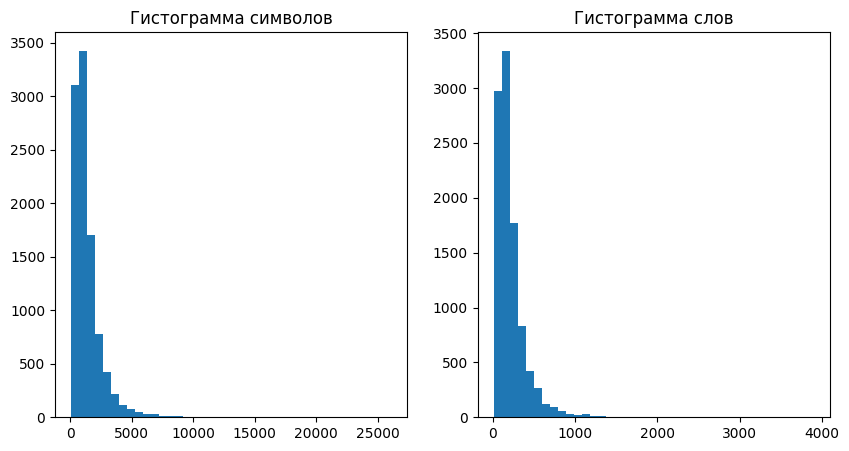

In [4]:
import matplotlib.pyplot as plt
from nltk.tokenize import RegexpTokenizer
regexp_words_tokenizer = RegexpTokenizer(r'\w+')

symbol_count_series = responses_df["text"].transform(lambda x:len(x))
words_count_series = responses_df["text"].transform(lambda x:len(regexp_words_tokenizer.tokenize(x)))

symbols_words_figure = plt.figure(figsize=(10, 5))

symbols_hist = symbols_words_figure.add_subplot(1, 2, 1)
symbols_hist.hist(symbol_count_series, bins=40)
symbols_hist.set_title("Гистограмма символов")

words_hist = symbols_words_figure.add_subplot(1, 2, 2)
words_hist.hist(words_count_series, bins=40)
words_hist.set_title("Гистограмма слов")

plt.show()

#### 3. Найдите 10 самых частых:
- слов
- слов без стоп-слов
- лемм
- существительных

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

def get_words_frequency(bow, features):
    word_usage = bow.sum(axis=0)
    words_usage_dict = np.stack((np.array(word_usage[0]).ravel(), features), axis=1)
    indices = np.argsort(-words_usage_dict[:, 0])
    return words_usage_dict[indices]

def get_most_popular_words(bow, features, count):
    return get_words_frequency(bow, features)[:count-1]

In [6]:
count_vectorizer = CountVectorizer(ngram_range=(1, 1))
bow_matrix = count_vectorizer.fit_transform(responses_df["text"])

most_popular_words = get_most_popular_words(bow_matrix, count_vectorizer.get_feature_names_out(), 10)
most_popular_words

array([[52558, 'не'],
       [42743, 'на'],
       [37607, 'что'],
       [22362, 'по'],
       [19729, 'мне'],
       [16597, 'банка'],
       [12712, 'банк'],
       [12273, 'но'],
       [12230, 'как']], dtype=object)

In [7]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = stopwords.words('russian') + ['г', 'гн', 'это' , 'тыс', 'млн', 'млрд', 'также',  'т', 'д',
    'который','прошлый','сей', 'свой', 'наш', 'мочь', 'такой', 'п']

count_vectorizer_no_stop_words = CountVectorizer(ngram_range=(1, 1), stop_words=stop_words)
bow_matrix_no_stop_words = count_vectorizer_no_stop_words.fit_transform(responses_df["text"])

most_popular_words_no_stop_words = get_most_popular_words(bow_matrix_no_stop_words, count_vectorizer_no_stop_words.get_feature_names_out(), 10)
most_popular_words_no_stop_words

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tyane\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


array([[16597, 'банка'],
       [12712, 'банк'],
       [8096, 'деньги'],
       [6424, 'карту'],
       [6077, 'карты'],
       [5337, 'кредит'],
       [4561, 'день'],
       [4381, 'очень'],
       [4335, 'банке']], dtype=object)

In [8]:
# Подготовим токенайзер с лемматизацией
from pymorphy2 import MorphAnalyzer

pymorphy2_analyzer = MorphAnalyzer()

def lemmatizer_tokenizer(text, stopwords = stop_words): 
    return [pymorphy2_analyzer.parse(word)[0].normal_form for word in text.split() if word not in stopwords]

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
# Здесь работу выполнил единожды и сохранил результаты, чтобы не пересчитывать
count_vectorizer_lemmas = CountVectorizer(ngram_range=(1, 1), tokenizer=lemmatizer_tokenizer)
bow_matrix_lemmas = count_vectorizer_lemmas.fit_transform(responses_df["text"])

most_popular_lemmas = get_most_popular_words(bow_matrix_lemmas, count_vectorizer_lemmas.get_feature_names_out(), 10)
most_popular_lemmas

c:\Users\tyane\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


array([[40067, 'банк'],
       [20195, 'карта'],
       [10990, 'деньга'],
       [10401, 'день'],
       [10190, 'кредит'],
       [9827, 'мой'],
       [8514, 'отделение'],
       [8301, 'клиент'],
       [8211, 'сотрудник']], dtype=object)

In [10]:
# Сохраним результаты работы CountVectorizer-а с лемматизатором
# from scipy.sparse import save_npz
# from joblib import dump

# save_npz('bow_matrix_lemmas.npz', bow_matrix_lemmas)
# dump(count_vectorizer_lemmas, 'count_vectorizer_lemmas.joblib')


In [11]:
# Загрузим результаты работы CountVectorizer-а с лемматизатором
# from scipy.sparse import load_npz
# from joblib import load

# count_vectorizer_lemmas = load('count_vectorizer_lemmas.joblib')
# bow_matrix_lemmas = load_npz('bow_matrix_lemmas.npz')
# most_popular_lemmas = get_most_popular_words(bow_matrix_lemmas, count_vectorizer_lemmas.get_feature_names_out(), 10)
# most_popular_lemmas

#### 4. Постройте кривые Ципфа и Хипса

In [12]:
bow_matrix_lemmas

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 952771 stored elements and shape (10000, 31378)>

Text(0.5, 1.0, 'Кривая Хипса')

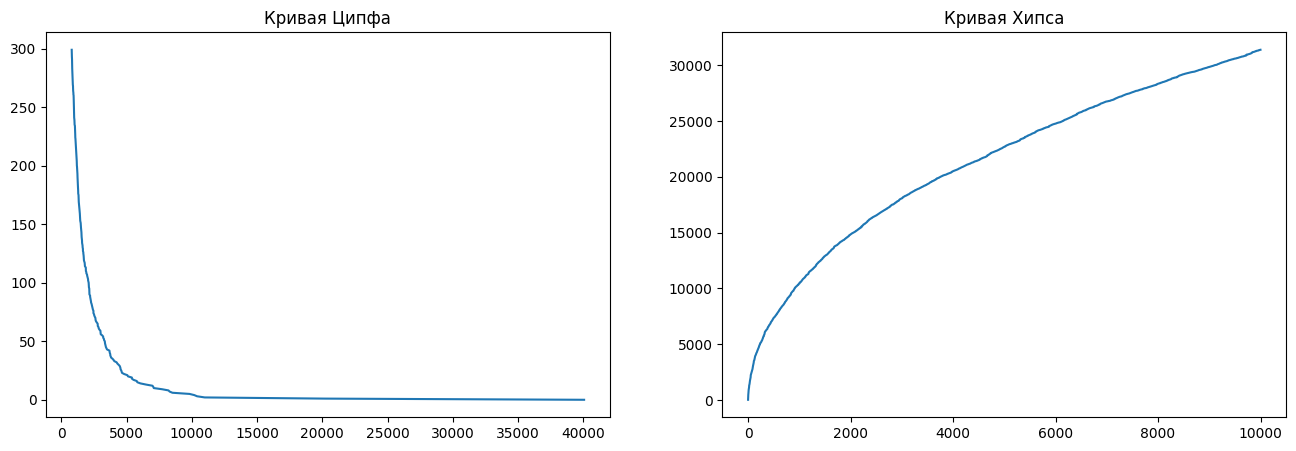

In [13]:
words_frequency = get_words_frequency(bow_matrix_lemmas, count_vectorizer_lemmas.get_feature_names_out())
words_frequency_values = words_frequency[:, 0]

zipf_heaps_figure = plt.figure(figsize=(16, 5))

# Кривая Ципфа
zipf_curve = zipf_heaps_figure.add_subplot(1, 2, 1)
zipf_curve.plot(words_frequency_values[:300], range(300))
zipf_curve.set_title("Кривая Ципфа")

# Кривая Хипса

# Построю кривую Хипса используя существующий мешок слов с лемматизацией
# Для каждого обработанного текста запомним уникальные значения
unique_words = set()
n_unique_words = []

for text_idx in range(10000):
    text = bow_matrix_lemmas.getrow(text_idx)
    unique_words.update(text.indices)
    n_unique_words.append(len(unique_words))
    
heaps_curve = zipf_heaps_figure.add_subplot(1, 2, 2)
heaps_curve.plot(n_unique_words[:100000])
heaps_curve.set_title("Кривая Хипса")

#### 5. Ответьте на следующие вопросы:
- какое слово встречается чаще, “сотрудник” или “клиент”?
- сколько раз встречается слова “мошенничество” и “доверие”?

In [14]:
def get_word_frequency(word, words_freq):
    words = words_freq[:, 1]
    word_index = np.argmax(words == word)
    return words_freq[word_index, 0]

emp_freq = get_word_frequency('сотрудник', words_frequency)
cliend_freq = get_word_frequency('клиент', words_frequency)
fraud_freq = get_word_frequency('мошенничество', words_frequency)
trust_freq = get_word_frequency('доверие', words_frequency)

print("Частота слов 'сотрудник' - {}, 'клиент' - {}, 'мошенничество' - {}, 'доверие' - {}.".format(emp_freq, cliend_freq, fraud_freq, trust_freq))

# Клиент встречается чаще сотрудника
# Мощенничество встречается чаще доверия

Частота слов 'сотрудник' - 8211, 'клиент' - 8301, 'мошенничество' - 203, 'доверие' - 132.


#### 6. В поле “rating_grade” записана оценка отзыва по шкале от 1 до 5. Используйте меру $tf-idf$, для того, чтобы найти ключевые слова и биграмы для положительных отзывов (с оценкой 5) и отрицательных отзывов (с оценкой 1)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer, TfidfTransformer

tfidf_vectorizer = TfidfVectorizer(tokenizer=lemmatizer_tokenizer, ngram_range=(1, 2))
tfidf = tfidf_vectorizer.fit_transform(responses_df["text"])

In [16]:
tfidf_vectorizer.get_feature_names_out()

array(['аа', 'аа даконтактный', 'аа далее', ..., 'ёмко выражать',
       'ёрзать', 'ёрзать стул'], shape=(653100,), dtype=object)

In [17]:
from collections import Counter

five_points_responses = responses_df[responses_df["rating_grade"] == 5]["text"]
one_point_responses = responses_df[responses_df["rating_grade"] == 1]["text"]

In [ ]:
# Здесь получим n самых "важных" слов для заданного текста
def text_most_valuable_words(text_tfidf, features, words_num = 5):
    word_scores = dict(zip(features, text_tfidf))
    sorted_words = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_words[:words_num]

def texts_most_valuable_words(text_indices, tfidf_matrix, features, words_num = 5):
    result = []
    for text_index in text_indices:
        text_tfidf = tfidf_matrix[text_index].toarray().flatten()
        result += text_most_valuable_words(text_tfidf, features, words_num)
    return np.array(result)

five_points_most_valuable_words = texts_most_valuable_words(five_points_responses.index, tfidf, tfidf_vectorizer.get_feature_names_out())
one_point_most_valuable_words = texts_most_valuable_words(one_point_responses.index, tfidf, tfidf_vectorizer.get_feature_names_out())

five_points_counts = Counter(five_points_most_valuable_words[:, 0])
one_point_counts = Counter(one_point_most_valuable_words[:, 0])
print("Наиболее распространенные ключевые n-граммы в положительных отзывах: {}".format(five_points_counts.most_common(10)))
print("Наиболее распространенные ключевые n-граммы в отрицательных отзывах: {}".format(one_point_counts.most_common(10)))

### Часть 2. Тематическое моделирование (Эта часть задания может быть сделана с использованием gensim.)
#### 1. Постройте несколько тематических моделей коллекции документов с разным числом тем. Приведите примеры понятных (интерпретируемых) тем.

In [19]:
from gensim.corpora import Dictionary
from gensim.models import TfidfModel
from gensim.models import lsimodel

In [20]:
dictionary_input = [lemmatizer_tokenizer(text) for text in responses_df.text]
#dictionary_input

In [21]:
dictionary = Dictionary(dictionary_input)
corpus = [dictionary.doc2bow(text) for text in dictionary_input]

In [22]:
tfidf = TfidfModel(corpus)
corpus_tfidf = tfidf[corpus]

In [23]:
lsi = lsimodel.LsiModel(corpus=corpus_tfidf, id2word=dictionary)
lsi.show_topics(20)

[(0,
  '0.195*"карта" + 0.141*"кредит" + 0.117*"деньга" + 0.107*"счёт" + 0.104*"вклад" + 0.104*"заявление" + 0.101*"отделение" + 0.100*"сумма" + 0.096*"банкомат" + 0.093*"платёж"'),
 (1,
  '-0.539*"вклад" + 0.305*"кредит" + 0.165*"платёж" + 0.153*"страховка" + 0.134*"задолженность" + -0.129*"очередь" + -0.127*"открыть" + 0.118*"погашение" + -0.109*"банкомат" + 0.107*"звонок"'),
 (2,
  '0.362*"вклад" + -0.294*"банкомат" + -0.268*"карта" + 0.253*"кредит" + -0.185*"сбербанк" + 0.170*"страховка" + -0.154*"деньга" + 0.143*"договор" + -0.139*"операция" + -0.126*"средство"'),
 (3,
  '-0.250*"вклад" + -0.224*"сумма" + -0.199*"руб" + 0.184*"номер" + -0.169*"рубль" + -0.166*"процент" + -0.164*"договор" + -0.159*"комиссия" + 0.154*"звонок" + -0.150*"платёж"'),
 (4,
  '-0.346*"вклад" + 0.238*"страховка" + 0.224*"карта" + -0.221*"номер" + -0.194*"звонок" + 0.166*"заявка" + 0.161*"кредит" + 0.155*"банкомат" + -0.125*"телефон" + -0.118*"ваш"'),
 (5,
  '-0.442*"банкомат" + 0.419*"карта" + 0.198*"лимит

Сложно подобрать такой набор тем при котором разбиение на темы даст какие-то четкие результаты. Но некоторые темы можно интерпретировать. 
Рассмотрим тему описанную словами:
'-0.362*"вклад" + 0.294*"банкомат" + 0.268*"карта" + -0.253*"кредит" + 0.185*"сбербанк" + -0.170*"страховка" + 0.154*"деньга" + -0.143*"договор" + 0.139*"операция" + 0.125*"средство"'
Здесь явно говорится о проблеме с получением или внесением денег, средств в банкомат по карте сбербанка, и НЕ говорится о вкладах, договорах, страховках.
Рассмотрим тему:
'0.346*"вклад" + -0.238*"страховка" + -0.223*"карта" + 0.221*"номер" + 0.194*"звонок" + -0.165*"заявка" + -0.162*"кредит" + -0.156*"банкомат" + 0.126*"телефон" + 0.118*"ваш"',
Имеем дело с звонком по вопросам вклада. Банкомат, карта, страховка, заявка здесь слова с отрицательным весом, то есть далеки от темы.


#### 2. Найдите темы, в которых упомянуты конкретные банки (Сбербанк, ВТБ, другой банк). Можете ли вы их прокомментировать / объяснить?

In [24]:
def topic_has_word(topic, word):
    return any(item[0].count(word.lower()) > 0 for item in topic)

for topic_id, topic in lsi.show_topics(num_words=20):
    for word_of_interest in ['Сбербанк', 'ВТБ', 'Альфабанк']:
        if topic_has_word(lsi.show_topic(topic_id), word_of_interest):
            print('Слово: {} содержится в теме: {}'.format(word_of_interest, lsi.show_topic(0, topn = 50)))


Слово: Сбербанк содержится в теме: [('карта', np.float64(0.1953982114680526)), ('кредит', np.float64(0.14067241684962142)), ('деньга', np.float64(0.11744876339199438)), ('счёт', np.float64(0.1069909101799661)), ('вклад', np.float64(0.1040089684349039)), ('заявление', np.float64(0.10367926888694771)), ('отделение', np.float64(0.10053184180980072)), ('сумма', np.float64(0.09966528933946028)), ('банкомат', np.float64(0.09569435551338483)), ('платёж', np.float64(0.09304424122454219)), ('сотрудник', np.float64(0.09065967639625078)), ('мой', np.float64(0.0900590746972339)), ('день', np.float64(0.08993361640742681)), ('кредитный', np.float64(0.08972782473706725)), ('сбербанк', np.float64(0.0888698500589975)), ('сказать', np.float64(0.08596026737975011)), ('договор', np.float64(0.08155818400975678)), ('номер', np.float64(0.08135162708248096)), ('год', np.float64(0.08000855423658942)), ('ваш', np.float64(0.07813467326567988)), ('рубль', np.float64(0.07754120167202344)), ('клиент', np.float64(0.

Имена банков в темах появляются с очень маленькими весами, делаю вывод, что имена банков не являются определяющими словами в темах

### Часть 3. Классификация текстов
Сформулируем для простоты задачу бинарной классификации: будем классифицировать на два класса, то есть, различать резко отрицательные отзывы (с оценкой 1) и положительные отзывы (с оценкой 5).

1. Составьте обучающее и тестовое множество: выберите из всего набора данных N1 отзывов с оценкой 1 и N2 отзывов с оценкой 5 (значение N1 и N2 – на ваше усмотрение). Используйте sklearn.model_selection.train_test_split для разделения множества отобранных документов на обучающее и тестовое.

In [25]:

x_points_responses = responses_df[(responses_df["rating_grade"] == 5) | (responses_df["rating_grade"] == 1)][["text","rating_grade"]]
x_points_responses["rating_grade"] = x_points_responses["rating_grade"].astype(int)
x_points_responses["text"] = x_points_responses["text"].transform(lemmatizer_tokenizer)


In [26]:
x_points_responses["text"] = x_points_responses["text"].transform(lambda words: ' '.join(words))
x_points_responses

,text,rating_grade
7,являться клиент петербургский бин банк филиал ...,1
11,просить откликнуться пострадать мошеннический ...,1
12,весь страна новогодний скидка сетель банк ново...,1
13,раз проблема сталкиваться погашать кредит год ...,1
14,далёкий год получить карта американа эксспресс...,1
...,...,...
9993,заявка кредит отделение сразу приходить смс пр...,1
9996,зао рахмановский шёлковый комбинат проходная о...,1
9997,поставить приложение тинькофф валгод телефон с...,1
9998,являться клиент кредит брать год платить своев...,1


In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_points_responses.text, x_points_responses.rating_grade, test_size=0.2, random_state=42)

2. Используйте любой известный вам алгоритм классификации текстов для решения задачи и получите baseline. Сравните разные варианты векторизации текста: использование только униграм, пар или троек слов или с использованием символьных $n$-грам.

In [30]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

vectorizers = [('TFIDF words 1-1', TfidfVectorizer(ngram_range=(1, 1))), 
                ('TFIDF words 2-2', TfidfVectorizer(ngram_range=(2, 2))), 
                ('TFIDF words 3-3', TfidfVectorizer(ngram_range=(3, 3))),
                ('TFIDF char 3-3', TfidfVectorizer(analyzer='char', ngram_range=(3, 3))),
                ('TFIDF char 5-5', TfidfVectorizer(analyzer='char', ngram_range=(5, 5)))
            ]

for name, vectorizer in vectorizers:
    bow = vectorizer.fit_transform(x_train)
    x_point_model = SVC()
    x_point_model.fit(bow, y_train)
    pred = x_point_model.predict(vectorizer.transform(x_test))
    print('Vectorizer {}'.format(name))
    print(classification_report(pred, y_test))

Vectorizer TFIDF words 1-1
              precision    recall  f1-score   support

           1       0.99      0.92      0.96       750
           5       0.80      0.98      0.88       243

    accuracy                           0.94       993
   macro avg       0.90      0.95      0.92       993
weighted avg       0.95      0.94      0.94       993

Vectorizer TFIDF words 2-2
              precision    recall  f1-score   support

           1       1.00      0.73      0.84       953
           5       0.13      1.00      0.24        40

    accuracy                           0.74       993
   macro avg       0.57      0.86      0.54       993
weighted avg       0.97      0.74      0.82       993

Vectorizer TFIDF words 3-3
              precision    recall  f1-score   support

           1       1.00      0.70      0.82       992
           5       0.00      1.00      0.01         1

    accuracy                           0.70       993
   macro avg       0.50      0.85      0.41    

3. Сравните, как изменяется качество решения задачи при использовании скрытых тем в качестве признаков:
    - 1-ый вариант: $tf-idf$ преобразование (sklearn.feature_extraction.text.TfidfTransformer) и сингулярное разложение (оно же – латентый семантический анализ) (sklearn.decomposition.TruncatedSVD),
    - 2-ой вариант: тематические модели LDA (sklearn.decomposition.LatentDirichletAllocation). Используйте accuracy и F-measure для оценки качества классификации.

In [39]:
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

# Соберем в пайплайн преобразование, векторизацию и 
pipeline = Pipeline([
    # здесь учитываем, что текст уже предобработан, лемматизирован и можно не добавлять никаких действий
    ('vectorizer1', TfidfVectorizer(ngram_range=(1, 2))),
    ('vectorizer2', TruncatedSVD(n_components=50, random_state=42)),
    ('classification', SVC())
])

pipeline.fit(x_train, y_train)
pred = pipeline.predict(x_test)
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

           1       0.99      0.94      0.96       726
           5       0.86      0.97      0.91       267

    accuracy                           0.95       993
   macro avg       0.92      0.95      0.94       993
weighted avg       0.95      0.95      0.95       993



In [38]:
from sklearn.decomposition import LatentDirichletAllocation

pipeline = Pipeline([
    # Текст уже предобработан, ничего делать не надо
    ('vectorizer1', CountVectorizer()),
    ('vectorizer2', LatentDirichletAllocation(n_components=80, random_state=42)),
    ('classification', SVC())
])

pipeline.fit(x_train, y_train)
pred = pipeline.predict(x_test)
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

           1       0.96      0.94      0.95       709
           5       0.86      0.90      0.88       284

    accuracy                           0.93       993
   macro avg       0.91      0.92      0.91       993
weighted avg       0.93      0.93      0.93       993



#### Выводы по 3 части
У меня получилось что на лемматизированном хорошо предобработанном тексте комбинация tf-idf метрики и SVC модели дает хорошие результаты для униграмм и для символьных триграмм. Для биграмм метрика качества ухудшается. Использование TruncatedSVD и LDA повышают качество, но незначитально. TruncatedSVD при взятии 100 главных компонент дает accuracy равную 96 - это лучший результат, который у меня получился. При использовании LDA улучшений нет после n_components=50.